# First-Order Linear SVR for $f' = -\lambda_\kappa f - \lambda e^{-\lambda_\kappa x}\sin(\lambda x)$

$$\frac{df}{dx} = -\lambda_\kappa f - \lambda e^{-\lambda_\kappa x}\sin(\lambda x),\qquad \lambda_\kappa=0.1,\ \lambda=20,\ f(0)=1,$$
analytic solution $f(x)=e^{-\lambda_\kappa x}\cos(\lambda x)$.

Write the DE as $f'(x) + p(x)f(x) + r(x)=0$ with $p(x)=\lambda_\kappa$, $r(x)=\lambda e^{-\lambda_\kappa x}\sin(\lambda x)$. Model $f(x)=w^\dagger\varphi(x)+b$, so the constraint at $x_i$ is $w^\dagger\big(\varphi'(x_i)+p_i\varphi(x_i)\big)+p_i b + r_i = e_i$.

Minimizing $\tfrac12 w^\dagger w + \tfrac{\gamma}{2}\sum_i e_i^2$ subject to those constraints and the IC $w^\dagger\varphi(x_0)+b=f_0$, the KKT conditions give
$$w=\sum_i\alpha_i\big(\varphi'(x_i)+p_i\varphi(x_i)\big)+\beta\,\varphi(x_0),\qquad \beta=-\sum_i\alpha_i p_i,\qquad e_i=-\alpha_i/\gamma.$$
Applying the kernel trick with $\kappa(u,v)=\varphi(u)^\dagger\varphi(v)$ and its derivatives $K^{[q,p]}=\partial_u^q\partial_v^p\kappa$ turns the stationarity equations into a single **linear** system in $(\alpha,b)$ (since the problem is linear, no $f^3$ dummy variables are needed). The fitted solution is
$$f(x)=\sum_j\alpha_j\big[K^{[1,0]}(x_j,x)+p_j K^{[0,0]}(x_j,x)\big]+\beta\,K^{[0,0]}(x_0,x)+b.$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

In [2]:
# ============================================================
# QUANTUM KERNEL (unchanged architecture, cached statevectors)
# ============================================================
def build_HEA(n_qubits=8, depth=1, seed=1):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2*np.pi, size=(depth, n_qubits, 2))
    qc = QuantumCircuit(n_qubits, name="HEA")
    for i in range(depth):
        for q in range(n_qubits):
            qc.rx(theta[i, q, 0], q); qc.rz(theta[i, q, 1], q)
        for q in range(n_qubits-1):
            qc.cx(q, q+1)
    return qc

def build_kernel_feature_map(n_qubits=8):
    x = Parameter("x")
    qc = QuantumCircuit(n_qubits, name="KernelMap")
    qc.compose(build_HEA(n_qubits, 1, seed=1), inplace=True)
    for q in range(n_qubits): qc.rx((q*x)/2, q)
    qc.compose(build_HEA(n_qubits, 1, seed=2), inplace=True)
    for q in range(n_qubits): qc.rx((q*x)/2, q)
    return qc

N_QUBITS = 5
_QC = build_kernel_feature_map(N_QUBITS)
_PX = [p for p in _QC.parameters if p.name == "x"][0]
_psi_cache = {}
def _psi(x):
    key = round(float(x), 12)
    if key not in _psi_cache:
        _psi_cache[key] = Statevector.from_instruction(_QC.assign_parameters({_PX: x})).data
    return _psi_cache[key]
def kappa(u, v):
    return np.abs(np.vdot(_psi(v), _psi(u)))**2

print("Kernel ready. kappa(0.3,0.3) =", round(kappa(0.3, 0.3), 6))

Kernel ready. kappa(0.3,0.3) = 1.0


In [3]:
# ============================================================
# KERNEL DERIVATIVES  K[q,p](u,v) = d^q/du^q d^p/dv^p kappa
# (q,p up to 1; mixed second derivative for K11)
# ============================================================
DERIV_H = 1e-3
def K00(u, v): return kappa(u, v)
def K10(u, v): return (kappa(u+DERIV_H, v) - kappa(u-DERIV_H, v)) / (2*DERIV_H)
def K01(u, v): return (kappa(u, v+DERIV_H) - kappa(u, v-DERIV_H)) / (2*DERIV_H)
def K11(u, v):
    return (kappa(u+DERIV_H, v+DERIV_H) - kappa(u+DERIV_H, v-DERIV_H)
            - kappa(u-DERIV_H, v+DERIV_H) + kappa(u-DERIV_H, v-DERIV_H)) / (4*DERIV_H**2)
print("Derivative helpers ready.")

Derivative helpers ready.


In [9]:
# ============================================================
# LINEAR ODE:  f' + p(x) f + r(x) = 0
# ============================================================
LAMBDA_K = 0.2      # p(x) = lambda_k  (constant coefficient of f)
LAMBDA   = 20.0
X0, F0   = 0.0, 1.0

def p_coef(x):  return LAMBDA_K          # coefficient of f (constant)
def r_fun(x):   return LAMBDA * np.exp(-LAMBDA_K * x) * np.sin(LAMBDA * x)
def f_exact(x): return np.exp(-LAMBDA_K * x) * np.cos(LAMBDA * x)

print(f"ODE: f' = -{LAMBDA_K} f - {LAMBDA} exp(-{LAMBDA_K} x) sin({LAMBDA} x),  f(0)={F0}")
print(f"Analytic solution: f(x) = exp(-{LAMBDA_K} x) cos({LAMBDA} x)")

ODE: f' = -0.2 f - 20.0 exp(-0.2 x) sin(20.0 x),  f(0)=1.0
Analytic solution: f(x) = exp(-0.2 x) cos(20.0 x)


In [10]:
# ============================================================
# LINEAR SVR SOLVER
# ============================================================
class LinearODESVRSolver:
    def __init__(self, x_train, gamma=1e5):
        self.X = np.asarray(x_train, float)
        self.N = len(self.X)
        self.gamma = gamma

    def fit(self, p_coef, r_fun, x0, f0):
        X, N = self.X, self.N
        p = np.array([float(p_coef(xi)) for xi in X])
        g = self.gamma

        # kernel matrices over the grid (computed once)
        M11 = np.array([[K11(X[j], X[i]) for j in range(N)] for i in range(N)])
        M10 = np.array([[K10(X[j], X[i]) for j in range(N)] for i in range(N)])
        M01 = np.array([[K01(X[j], X[i]) for j in range(N)] for i in range(N)])
        M00 = np.array([[K00(X[j], X[i]) for j in range(N)] for i in range(N)])
        b01 = np.array([K01(x0, X[i]) for i in range(N)])
        b00 = np.array([K00(x0, X[i]) for i in range(N)])
        c10 = np.array([K10(X[j], x0) for j in range(N)])
        c00 = np.array([K00(X[j], x0) for j in range(N)])
        s00 = K00(x0, x0)

        # assemble (N+1) x (N+1) linear system for [alpha, b]; beta = -sum_j alpha_j p_j
        A = np.zeros((N+1, N+1)); rhs = np.zeros(N+1)
        for i in range(N):
            for j in range(N):
                core = M11[i,j] + p[i]*M10[i,j] + p[j]*M01[i,j] + p[i]*p[j]*M00[i,j]
                if i == j: core += 1.0/g
                beta_term = -p[j]*(b01[i] + p[i]*b00[i])
                A[i, j] = core + beta_term
            A[i, N] = p[i]
            rhs[i]  = -r_fun(X[i])
        for j in range(N):
            A[N, j] = c10[j] + p[j]*c00[j] - p[j]*s00
        A[N, N] = 1.0
        rhs[N]  = f0

        sol = np.linalg.solve(A, rhs)
        self.alpha = sol[:N]
        self.b     = sol[N]
        self.beta  = -np.sum(self.alpha * p)
        self.p, self.x0 = p, x0
        print(f"Solved {N+1}x{N+1} linear system | cond(A) = {np.linalg.cond(A):.2e}")
        return self

    def predict(self, x_eval):
        X, N, p = self.X, self.N, self.p
        out = []
        for x in np.atleast_1d(np.asarray(x_eval, float)):
            val = (sum(self.alpha[j]*(K10(X[j], x) + p[j]*K00(X[j], x)) for j in range(N))
                   + self.beta*K00(self.x0, x) + self.b)
            out.append(val)
        return np.array(out)

print("Linear SVR solver defined.")

Linear SVR solver defined.


In [11]:
# ============================================================
# SOLVE  (paper setup: 21 points, gamma = 1e5)
# ============================================================
x_train = np.linspace(0, 1, 21)
x_test  = np.linspace(0, 1, 200)

solver = LinearODESVRSolver(x_train, gamma=1e5)
solver.fit(p_coef, r_fun, X0, F0)

f_pred = solver.predict(x_test)
f_ref  = f_exact(x_test)
err = np.abs(f_pred - f_ref); rng = f_ref.max() - f_ref.min()
print(f"\nf_pred(0) = {f_pred[0]:.6f}  (target {F0})")
print(f"max abs error      = {err.max():.4e}")
print(f"mean abs error     = {err.mean():.4e}")
print(f"max normalized err = {err.max()/rng:.4e}")

Solved 22x22 linear system | cond(A) = 1.90e+07

f_pred(0) = 1.000000  (target 1.0)
max abs error      = 4.2379e-04
mean abs error     = 1.8013e-04
max normalized err = 2.1523e-04


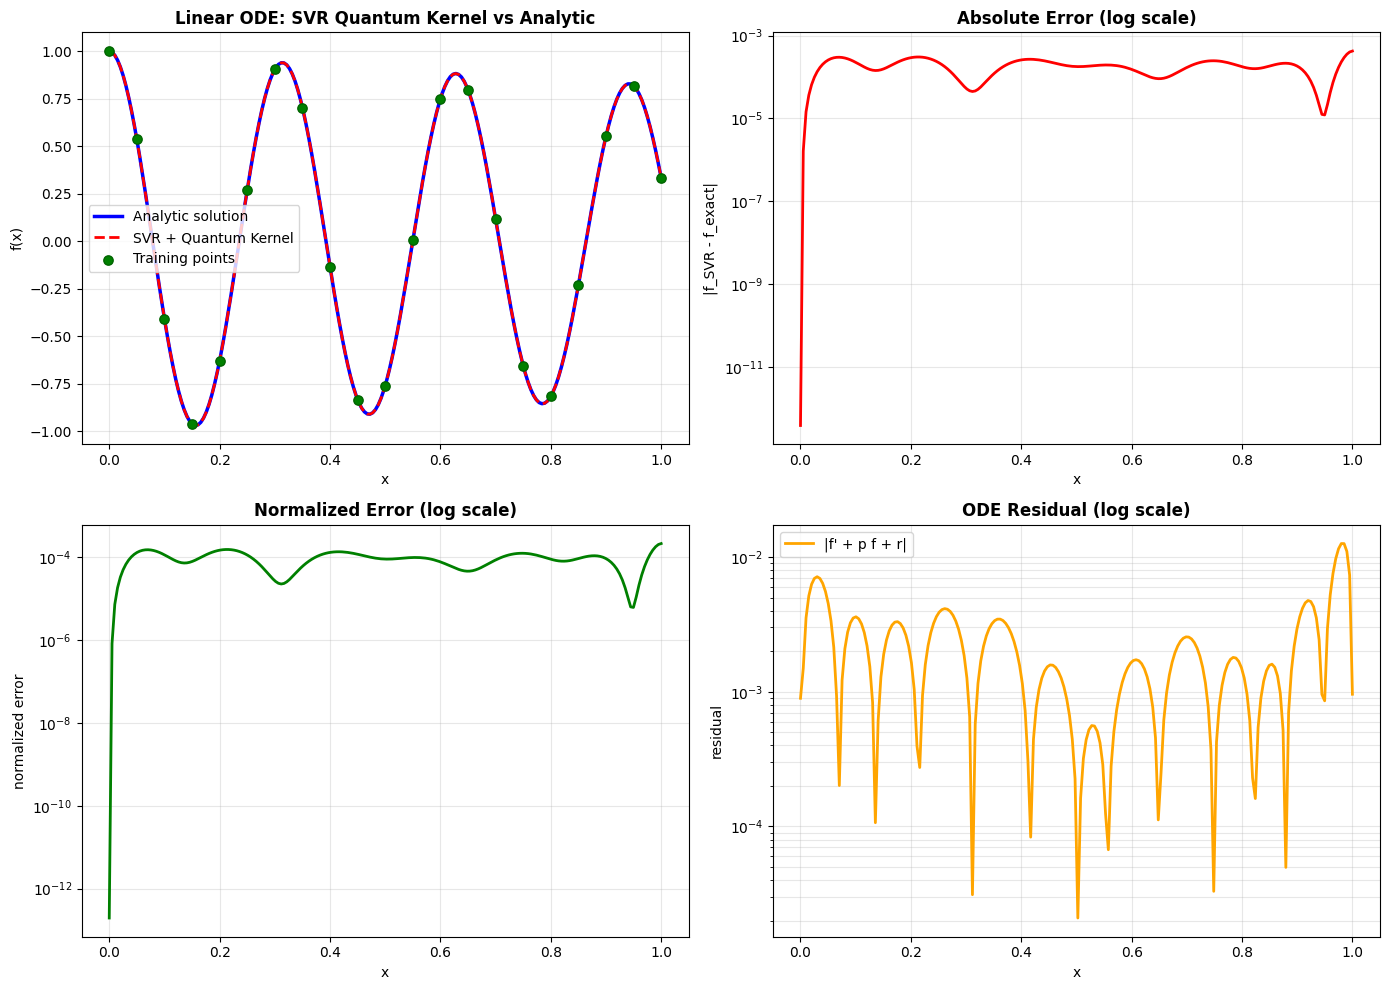

In [12]:
# ============================================================
# PLOTS
# ============================================================
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0,0].plot(x_test, f_ref, "b-", lw=2.5, label="Analytic solution")
ax[0,0].plot(x_test, f_pred, "r--", lw=2, label="SVR + Quantum Kernel")
ax[0,0].scatter(x_train, f_exact(x_train), color="green", s=45, zorder=5,
                edgecolors="darkgreen", label="Training points")
ax[0,0].set_xlabel("x"); ax[0,0].set_ylabel("f(x)")
ax[0,0].set_title("Linear ODE: SVR Quantum Kernel vs Analytic", fontweight="bold")
ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

ax[0,1].semilogy(x_test, err, "r-", lw=2)
ax[0,1].set_xlabel("x"); ax[0,1].set_ylabel("|f_SVR - f_exact|")
ax[0,1].set_title("Absolute Error (log scale)", fontweight="bold")
ax[0,1].grid(alpha=0.3, which="both")

norm_err = err / rng
ax[1,0].semilogy(x_test, norm_err, "g-", lw=2)
ax[1,0].set_xlabel("x"); ax[1,0].set_ylabel("normalized error")
ax[1,0].set_title("Normalized Error (log scale)", fontweight="bold")
ax[1,0].grid(alpha=0.3, which="both")

eps = 1e-4
df = (solver.predict(x_test+eps) - solver.predict(x_test-eps)) / (2*eps)
residual = np.abs(df + LAMBDA_K*f_pred + r_fun(x_test))
ax[1,1].semilogy(x_test, residual, color="orange", lw=2, label="|f' + p f + r|")
ax[1,1].set_xlabel("x"); ax[1,1].set_ylabel("residual")
ax[1,1].set_title("ODE Residual (log scale)", fontweight="bold")
ax[1,1].legend(); ax[1,1].grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()

In [13]:
# ============================================================
# SUMMARY
# ============================================================
print("="*64)
print("LINEAR ODE  -  FIRST-ORDER SVR (QUANTUM KERNEL)")
print("="*64)
print(f"Equation : f' = -{LAMBDA_K} f - {LAMBDA} exp(-{LAMBDA_K} x) sin({LAMBDA} x)")
print(f"IC       : f(0) = {F0}")
print(f"Kernel   : 2x(HEA depth-1 + feature map), {N_QUBITS} qubits")
print(f"Training : {len(x_train)} points, gamma = {solver.gamma:.0e}")
print("-"*64)
print(f"f_pred(0)            = {f_pred[0]:.6f}  (target {F0})")
print(f"max absolute error   = {err.max():.4e}")
print(f"mean absolute error  = {err.mean():.4e}")
print(f"max normalized error = {err.max()/rng:.4e}")
print(f"(paper Fig. 5 reports normalized error below ~2e-3)")
print("="*64)

LINEAR ODE  -  FIRST-ORDER SVR (QUANTUM KERNEL)
Equation : f' = -0.2 f - 20.0 exp(-0.2 x) sin(20.0 x)
IC       : f(0) = 1.0
Kernel   : 2x(HEA depth-1 + feature map), 8 qubits
Training : 21 points, gamma = 1e+05
----------------------------------------------------------------
f_pred(0)            = 1.000000  (target 1.0)
max absolute error   = 4.2379e-04
mean absolute error  = 1.8013e-04
max normalized error = 2.1523e-04
(paper Fig. 5 reports normalized error below ~2e-3)
